# Read and write shapefile
This notebook shows how to load a shapefile into a networkx objet, or save a shapefile from a networkx graph object

In [1]:
import karstnet as kn
import networkx as nx

## Read .shp

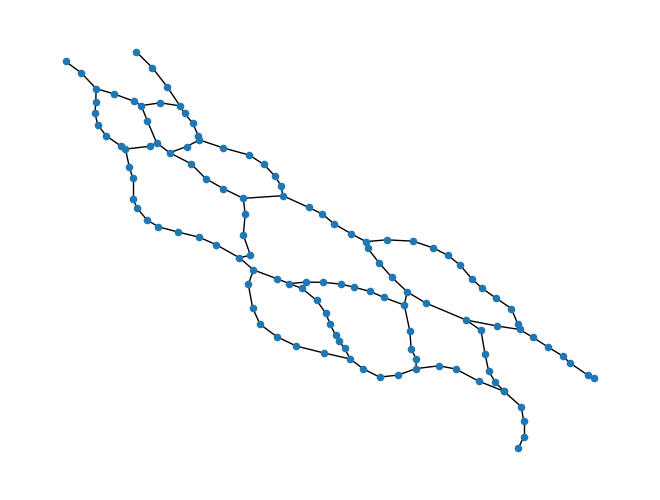

In [4]:
# path_to_shapefile = r'..\data\anastomotic-shapefile\AnastomoticPalmer.shp' 
path_to_shapefile = r'../data/anastomotic-shapefile/AnastomoticPalmer.shp' 
G = kn.io_func.networkx_from_shapefile(path_to_shapefile,precision=1)
nx.draw(G, pos=kn.utils.get_pos2d(G), node_size=20)

## Write .shp

In [10]:
# Import the cave Migovec with the attributes 'pos' (essentiel for shapefile export) and 'flags'
H = kn.io_func.networkx_from_yaml(r'..\data\047_Seefeldhoele_000\047_Seefeldhoele_000.yaml',
                                  add_node_attr=['pos','flags'],
                                  add_edge_attr=['flags'])
crs = H.graph['local_coordinate_system']
name = H.graph['short_name']

### Save all the nodes and edges

In [11]:
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=name,
                                outputdir=r'..\data\test_export_examples',
                                pos_attr='pos')

### Save only the entrances as a point shapefile

In [12]:
# extract all the nodes that have a flag entrance
entrances = kn.utils.find_flagged_nodes(H,'flags','ent')
print(f'entrances: {entrances}')

entrances: [520, 336]


In [13]:
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=f'{name}-entrances',
                                outputdir=r'..\data\test_export_examples',
                                line=False,
                                selected_nodes= entrances,
                                pos_attr='pos')

### Save only the edges as a line shapefile

In [14]:
#extract all the edges with the flag 'add'
additional_edges = kn.utils.find_flagged_edges(H,'flags','add')
print(f'additional_edges: {additional_edges}')

additional_edges: [(15, 81), (564, 40), (626, 83), (744, 592), (399, 552), (7, 166), (211, 417), (21, 711), (704, 89), (595, 501), (320, 256), (723, 264), (450, 460), (381, 170), (206, 191), (665, 134)]


In [16]:
crs = H.graph['local_coordinate_system']
name = H.graph['short_name']
kn.io_func.networkx_to_shapefile(H,
                                crs,
                                name=f'{name}-AdditionalEdges',
                                outputdir='../data/test_export_examples',
                                point=False,
                                selected_edges = additional_edges,
                                pos_attr='pos')